c:\Users\laris\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[5.35088544e-02 2.30255431e-04 1.19172067e-01 ... 2.54965394e-01
 7.19168462e-03 4.29142011e-01]


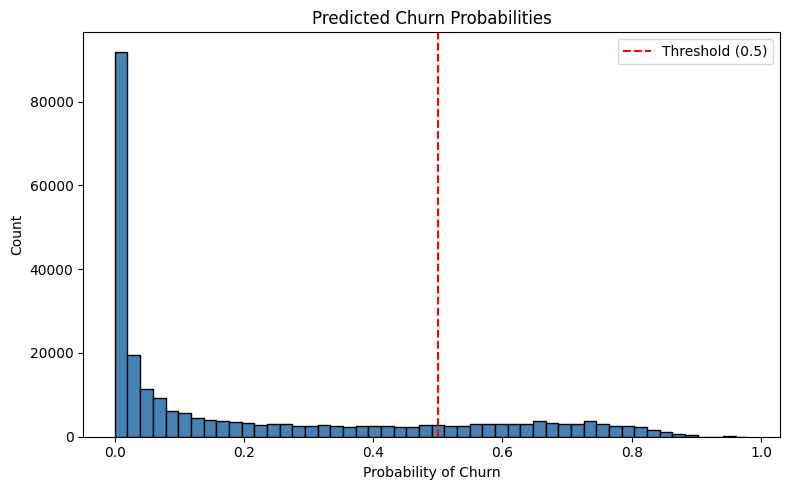

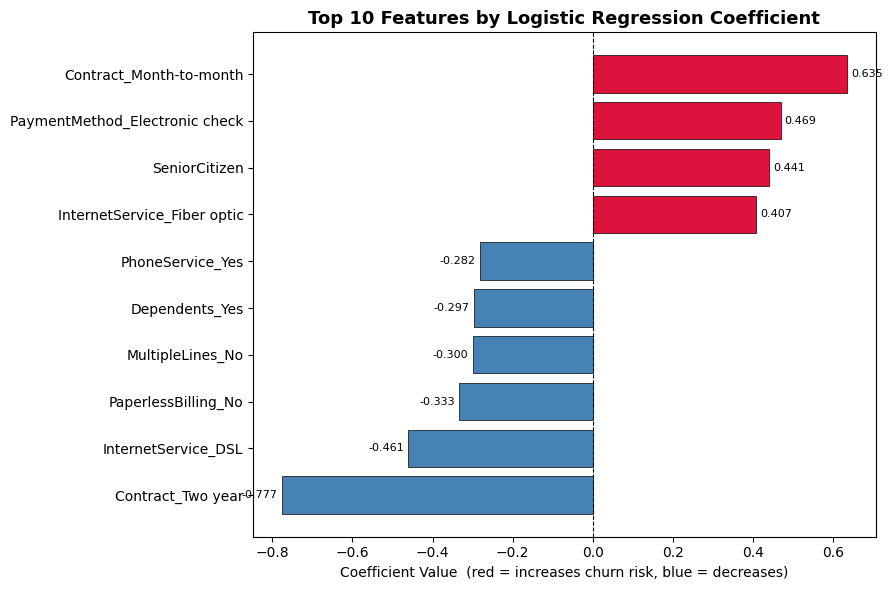

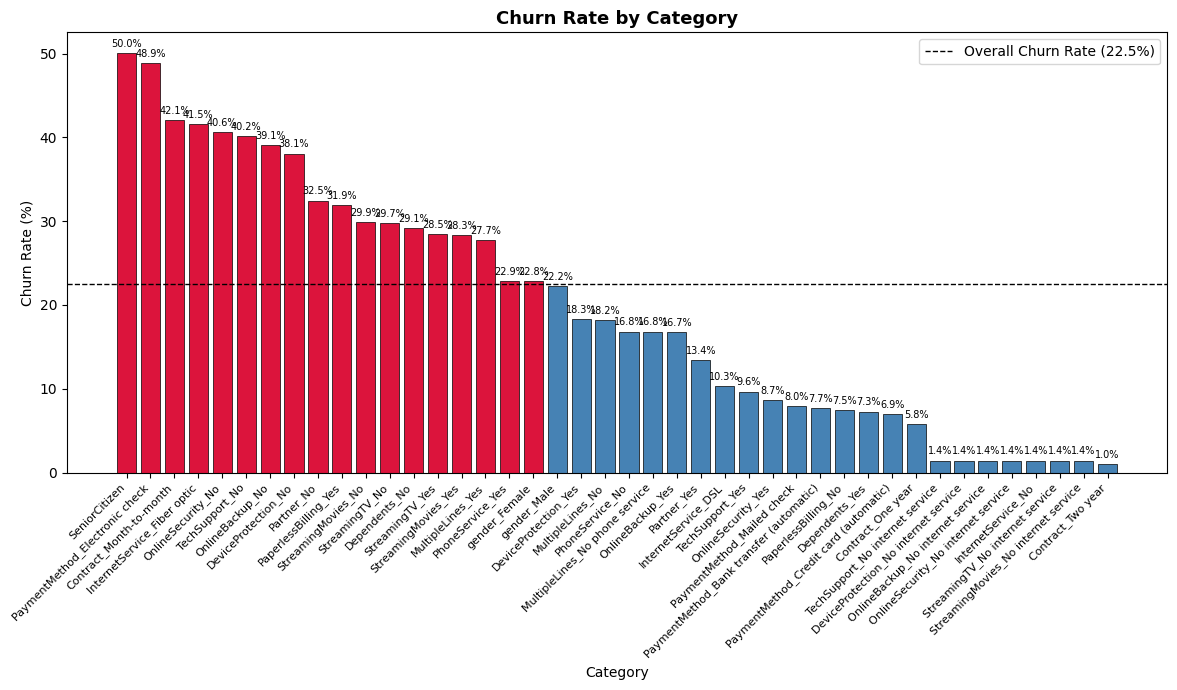

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# --- Load your data ---
trainData = pd.read_csv('train_processed.csv')
testData = pd.read_csv('test_processed.csv')

# --- Train the logistic regression model ---
X_train = trainData.drop('Churn', axis=1)
y_train = trainData['Churn']

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

predictions = model.predict_proba(testData)[:, 1]
print(predictions)

# --- Visualization of predicted probabilities ---
#Histogram of predicted probabilities

# --- Plot ---
threshold = 0.5

plt.figure(figsize=(8, 5))
plt.hist(predictions, bins=50, color='steelblue', edgecolor='black')
plt.axvline(x=threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')
plt.title('Predicted Churn Probabilities')
plt.xlabel('Probability of Churn')
plt.ylabel('Count')
plt.legend()   # safe to call — axvline provides the label
plt.tight_layout()
plt.show()


# ================================================================
# PART 1 — Top 15 Most Impactful Features
# ================================================================

# Get the coefficient for each feature
# Positive = increases churn risk, Negative = decreases churn risk
coefficients = pd.Series(model.coef_[0], index=X_train.columns)

# Sort by absolute value to find the most impactful features
top15 = coefficients.abs().nlargest(15).index

# Get the actual coefficient values for those top 15 features
top15_coefs = coefficients[top15].sort_values()

# Color the bars based on whether they increase or decrease churn
bar_colors = []
for value in top15_coefs:
    if value > 0:
        bar_colors.append('crimson')   # increases churn risk
    else:
        bar_colors.append('steelblue') # decreases churn risk

# Plot
plt.figure(figsize=(9, 6))
plt.barh(top15_coefs.index, top15_coefs.values, color=bar_colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--')
plt.title('Top 15 Features That Influence Churn')
plt.xlabel('Coefficient Value (red = more churn, blue = less churn)')
plt.tight_layout()
plt.show()

# ================================================================
# PART 2 — Churn Rate by Category
# ================================================================

# These are the numeric columns in our dataset — everything else is a category
numeric_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Find all the category columns (they only contain 0s and 1s)
category_columns = []
for col in X_train.columns:
    if col not in numeric_columns and X_train[col].nunique() == 2:
        category_columns.append(col)

# For each category, calculate the churn rate of customers in that category
churn_rates = {}
for col in category_columns:
    # Find all customers who belong to this category
    customers_in_category = X_train[col] == 1

    # Skip if no customers belong to this category
    if customers_in_category.sum() == 0:
        continue

    # Calculate what percentage of those customers churned
    churn_rate = y_train[customers_in_category].mean() * 100
    churn_rates[col] = churn_rate

# Put results into a dataframe and sort highest to lowest
churn_df = pd.DataFrame({
    'Category': list(churn_rates.keys()),
    'ChurnRate': list(churn_rates.values())
})
churn_df = churn_df.sort_values('ChurnRate', ascending=False).reset_index(drop=True)

# Calculate the overall churn rate to use as a reference line
overall_churn_rate = y_train.mean() * 100

# Color bars red if above average churn, blue if below
bar_colors2 = []
for rate in churn_df['ChurnRate']:
    if rate > overall_churn_rate:
        bar_colors2.append('crimson')   # higher churn than average
    else:
        bar_colors2.append('steelblue') # lower churn than average

# Plot
plt.figure(figsize=(12, 7))
plt.bar(churn_df['Category'], churn_df['ChurnRate'], color=bar_colors2, edgecolor='black')
plt.axhline(y=overall_churn_rate, color='black', linestyle='--',
            label=f'Overall Churn Rate ({overall_churn_rate:.1f}%)')
plt.title('Churn Rate by Category')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Category')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.legend()
plt.tight_layout()
plt.show()